In [ ]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
from statsmodels.datasets import get_rdataset
import sklearn.model_selection as skm
from sklearn.model_selection import train_test_split,GridSearchCV
from ISLP import load_data , confusion_table
from ISLP.models import ModelSpec as MS

In [ ]:
from sklearn.tree import (DecisionTreeClassifier as DTC,
DecisionTreeRegressor as DTR,
plot_tree,export_text)
from sklearn.metrics import (accuracy_score, roc_auc_score,log_loss,mean_squared_error,make_scorer,precision_score)
from sklearn.ensemble import \
(RandomForestRegressor as RF,
GradientBoostingRegressor as GBR)
from ISLP.bart import BART
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from ISLP import load_data
boston=load_data("Boston")
X = boston.drop(columns='medv')
y = boston['medv']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=8)



In [ ]:
### Linear Regression ###
lm = LinearRegression()
lm.fit(X_train, y_train)
lm_pred = lm.predict(X_test)
mse_lm = mean_squared_error(y_test, lm_pred)
print(f"Linear Regression MSE: {mse_lm:.4f}")

Linear Regression MSE: 26.7580


In [ ]:
model = MS(boston.columns.drop('medv'), intercept=False)
D = model.fit_transform(boston)
feature_names = list(D.columns)
X = np.asarray(D)

In [ ]:
#  bagged regression tree
bag_boston = RF(max_features=X_train.shape[1], random_state=0)
bag_boston.fit(X_train , y_train)
y_hat_bag = bag_boston.predict(X_test)
ax = subplots(figsize=(12,12))[1]
ax.scatter(y_hat_bag , y_test)

In [ ]:
mse_tree_bag = mean_squared_error(y_test, y_hat_bag)
print(f"bagged Tree MSE: {mse_tree_bag:.4f}")

bagged Tree MSE: 13.1590


In [ ]:
# change the number of trees
bag_boston = RF(max_features=X_train.shape[1],
n_estimators=500,
random_state=0).fit(X_train , y_train)

y_hat_bag = bag_boston.predict(X_test)
mse_tree_bag = mean_squared_error(y_test, y_hat_bag)
print(f"bagged Tree MSE: {mse_tree_bag:.4f}")


bagged Tree MSE: 13.3862


In [ ]:
# random forest
rf_boston = RF(max_features=3,
n_estimators=500,
random_state=0).fit(X_train , y_train)

y_hat_bag = rf_boston.predict(X_test)
mse_tree_bag = mean_squared_error(y_test, y_hat_bag)
print(f"bagged Tree MSE: {mse_tree_bag:.4f}")

bagged Tree MSE: 13.6015


In [ ]:
feature_imp = pd.DataFrame(
{'importance':rf_boston.feature_importances_},
index=feature_names)
feature_imp.sort_values(by='importance', ascending=False)

,importance
lstat,0.301727
rm,0.222060
crim,0.073161
indus,0.069640
nox,0.068751
dis,0.066875
ptratio,0.066297
age,0.052038
tax,0.030727
zn,0.030698


<ipython-input-14-de441d2a21eb>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances, y=features, palette='viridis')


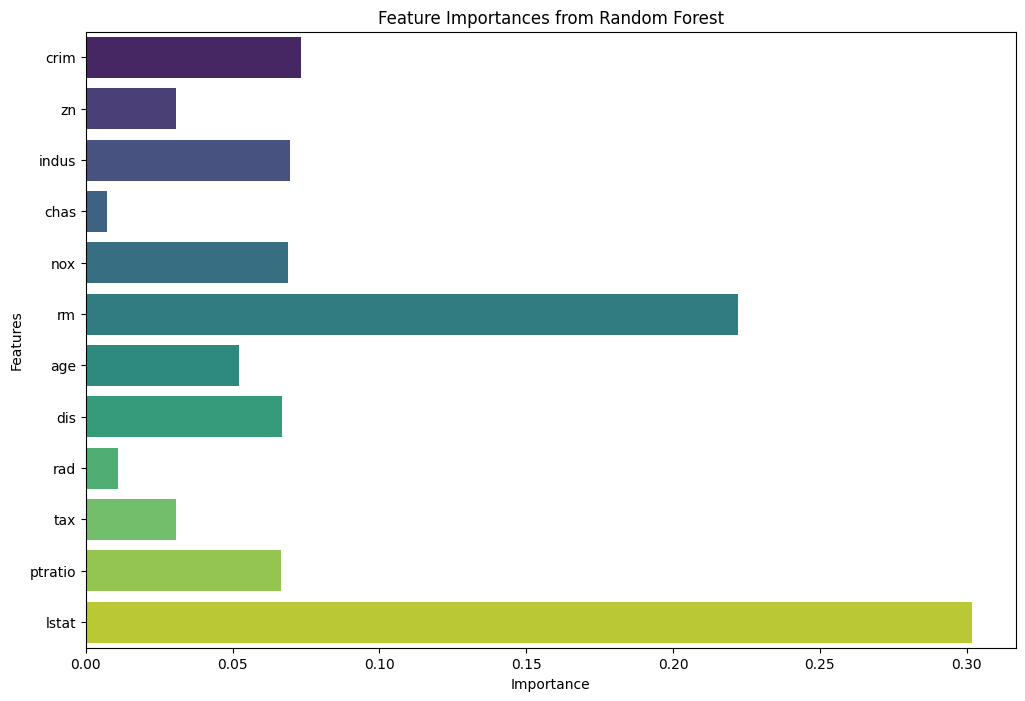

In [ ]:
feature_importances = rf_boston.feature_importances_
features = feature_names

plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importances, y=features, palette='viridis')
plt.title('Feature Importances from Random Forest')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

In [ ]:
###cross-validation###
# Define hyperparameters grid for Random Forest
param_grid = {
    'n_estimators': [100, 500],
    'max_features': ['sqrt',.5],
    'max_depth': [2, 5, 10, 15,20],
    'min_samples_split': [5,10],
    'min_samples_leaf': [4,6,8]
}

# Initialize the Random Forest Regressor
rf_model = RF(random_state=0)

# Define GridSearchCV
grid_search = GridSearchCV(estimator=rf_model,
                           param_grid=param_grid,
                           scoring='neg_mean_squared_error',
                           cv=5,  # 5-fold cross-validation
                           n_jobs=-1,  # Use all available processors
                           verbose=1)

# Fit GridSearchCV on the training data
grid_search.fit(X_train, y_train)

# Get the best parameters
best_params = grid_search.best_params_
print(f"Best Hyperparameters: {best_params}")



Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best Hyperparameters: {'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 500}


In [ ]:
# Get the best estimator from GridSearchCV
best_rf_model = grid_search.best_estimator_

# Make predictions on the test set using the best model
y_pred = best_rf_model.predict(X_test)

# Calculate the mean squared error
mse_best_rf = mean_squared_error(y_test, y_pred)
print(f"Test Set MSE with Best Parameters: {mse_best_rf:.4f}")


Test Set MSE with Best Parameters: 15.2247


In [ ]:
# Load the Caravan dataset
caravan = load_data("Caravan")

# Prepare features and target
X_caravan = caravan.drop(columns='Purchase')
y_caravan = caravan['Purchase']

# Encode the target variable
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_caravan)  # Converts 'No' -> 0 and 'Yes' -> 1

# Train-Test split using train_test_split
X_train_caravan, X_test_caravan, y_train_caravan, y_test_caravan = train_test_split(
    X_caravan, y_encoded, test_size=0.5, random_state=8)


In [ ]:
#  bagged classification tree
bag_boston = RF(max_features=X_train_caravan.shape[1], random_state=0)
bag_boston.fit(X_train_caravan, y_train_caravan)
y_hat_bag = bag_boston.predict(X_test_caravan)
print(y_hat_bag)

[0.   0.   0.07 ... 0.09 0.02 0.  ]


In [ ]:
y_hat_bag1 = (y_hat_bag > 0.5).astype(int)
test_accuracy =accuracy_score(y_test_caravan, y_hat_bag1)
print(f"Test set accuracy of the pruned tree: {test_accuracy:.4f}")
confusion = confusion_table(y_hat_bag1,y_test_caravan)
confusion

Test set accuracy of the pruned tree: 0.9303


Truth,0,1
Predicted,,
0,2701,162
1,41,7


In [ ]:
# Calculate the AUC
auc_score = roc_auc_score(y_test_caravan, y_hat_bag)
print(f"AUC Score: {auc_score:.4f}")

AUC Score: 0.6860


In [ ]:
print(X_train_caravan.shape[1])

In [ ]:
np.sqrt(85)/3

In [ ]:
###random forest
bag_boston = RF(max_features='sqrt', random_state=0)
bag_boston.fit(X_train_caravan, y_train_caravan)
y_hat_bag = bag_boston.predict(X_test_caravan)
print(y_hat_bag)

[0.08 0.08 0.03 ... 0.1  0.   0.03]


In [ ]:
y_hat_bag1 = (y_hat_bag > 0.5).astype(int)
test_accuracy =accuracy_score(y_test_caravan, y_hat_bag1)
print(f"Test set accuracy of the pruned tree: {test_accuracy:.4f}")
confusion = confusion_table(y_hat_bag1,y_test_caravan)
confusion

Test set accuracy of the pruned tree: 0.9347


Truth,0,1
Predicted,,
0,2714,162
1,28,7


In [ ]:
auc_score = roc_auc_score(y_test_caravan, y_hat_bag)
print(f"AUC Score: {auc_score:.4f}")

AUC Score: 0.6830


In [ ]:
###cross-validation###
# Define hyperparameters grid for Random Forest
param_grid = {
    'n_estimators': [100, 500],
    'max_features': ['sqrt',.5],
    'max_depth': [10, 30],
    'min_samples_split': [2,10],
    'min_samples_leaf': [1,5]
}

# Initialize the Random Forest Regressor
rf_model = RF(random_state=0)

# Define GridSearchCV
grid_search = GridSearchCV(estimator=rf_model,
                           param_grid=param_grid,
                           scoring='accuracy', ##should change according to your purpose
                           cv=5,  # 5-fold cross-validation
                           n_jobs=-1,  # Use all available processors
                           verbose=1)

# Fit GridSearchCV on the training data
grid_search.fit(X_train_caravan, y_train_caravan)

# Get the best parameters
best_params = grid_search.best_params_
print(f"Best Hyperparameters: {best_params}")

In [ ]:
# Get the best estimator from GridSearchCV
best_rf_model = grid_search.best_estimator_

# Make predictions on the test set using the best model
y_hat_bag = best_rf_model.predict(X_test_caravan)
print(y_hat_bag)

In [ ]:
y_hat_bag1 = (y_hat_bag > 0.5).astype(int)
test_accuracy =accuracy_score(y_test_caravan, y_hat_bag1)
print(f"Test set accuracy of the pruned tree: {test_accuracy:.4f}")
confusion = confusion_table(y_hat_bag1,y_test_caravan)
confusion

In [ ]:
auc_score = roc_auc_score(y_test_caravan, y_hat_bag)
print(f"AUC Score: {auc_score:.4f}")